# 3D Printed Layer Quality Detection

This notebook implements a complete ML pipeline to classify images of 3D-printed layers into three quality categories:
- `low_temp_rough` → label 0
- `good_layers` → label 1
- `too_melty` → label 2

In [8]:
import sys, subprocess

def install(packages):
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet'] + packages
    subprocess.check_call(cmd)

# Standard imports
import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from skimage.feature import graycomatrix, graycoprops
try:
    import tensorflow as tf
    from tensorflow import keras
except Exception:
    install(['tensorflow'])
    import tensorflow as tf
    from tensorflow import keras

RANDOM_STATE = 42
DATASET_PATH = 'dataset'
CLASS_MAP = { 'low_temp_rough': 0, 'good_layers': 1, 'too_melty': 2 }
INV_CLASS_MAP = {v: k for k, v in CLASS_MAP.items()}

## Section 2 — Image Loading Function
The `load_images` function below walks the dataset directory, reads JPG/PNG images using OpenCV, resizes them to a fixed size, converts to grayscale, and returns image arrays and labels.

In [9]:
## Image loading (grayscale, 256×256)

def load_images(dataset_path, image_size=(256,256)):
    images = []
    labels = []
    counts = {}
    for class_name, label in CLASS_MAP.items():
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_dir):
            print(f'Warning: class folder not found: {class_dir}')
            continue
        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        counts[class_name] = len(files)
        for fname in files:
            fpath = os.path.join(class_dir, fname)
            img = cv2.imread(fpath, cv2.IMREAD_COLOR)
            if img is None:
                continue
            img = cv2.resize(img, image_size, interpolation=cv2.INTER_AREA)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(label)
    if len(images) == 0:
        raise ValueError('No images found. Check DATASET_PATH and folder structure.')
    print('Images per class:', counts)
    return np.array(images), np.array(labels)

## Section 3 — Feature Extraction
We compute a compact set of handcrafted features per image: mean, std, Laplacian variance (sharpness), Sobel gradient magnitude mean, Canny edge density, GLCM contrast & homogeneity (using reduced gray levels), and FFT high-frequency energy ratio.

In [10]:
## Feature extraction (8 features)

def extract_features(image):
    # image: 2D grayscale uint8
    mean_int = float(np.mean(image))
    std_int = float(np.std(image))
    lap_var = float(cv2.Laplacian(image, cv2.CV_64F).var())
    sobelx = cv2.Sobel(image.astype('float32'), cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image.astype('float32'), cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    sobel_mean = float(np.mean(grad_mag))
    edges = cv2.Canny(image, 100, 200)
    edge_density = float(np.count_nonzero(edges) / (image.shape[0] * image.shape[1]))
    levels = 8
    img_small = (image / (256 // levels)).astype('uint8')
    try:
        glcm = graycomatrix(img_small, distances=[1], angles=[0], levels=levels, symmetric=True, normed=True)
        contrast = float(graycoprops(glcm, 'contrast')[0,0])
        homogeneity = float(graycoprops(glcm, 'homogeneity')[0,0])
    except Exception:
        contrast = 0.0
        homogeneity = 0.0
    f = np.fft.fft2(image.astype('float32'))
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    r = int(0.1 * min(rows, cols))
    Y, X = np.ogrid[:rows, :cols]
    mask = (X - ccol)**2 + (Y - crow)**2 <= r*r
    low_energy = np.sum(magnitude[mask]) + 1e-8
    total_energy = np.sum(magnitude) + 1e-8
    high_freq_ratio = float((total_energy - low_energy) / total_energy)
    feats = [mean_int, std_int, lap_var, sobel_mean, edge_density, contrast, homogeneity, high_freq_ratio]
    return np.array(feats, dtype=float)


def build_feature_matrix(X_images):
    features = []
    for img in tqdm(X_images, desc='Extracting features'):
        features.append(extract_features(img))
    return np.vstack(features)

## Section 4 — Data Augmentation
We augment the data by 6 times and performing transformations on the input data.

In [11]:
# Load images and extract features
print('Loading images from', DATASET_PATH)
X_images, y = load_images(DATASET_PATH, image_size=(256,256))
print('Total images loaded:', len(X_images))
# Optionally perform augmentation (match original notebook)
try:
    import albumentations as A
except Exception:
    install(['albumentations', 'imgaug'])
    import albumentations as A

AUG_PER_IMAGE = 6  # number of augmented copies per original image (adjust as needed)
transform = A.Compose([
    A.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.6),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.2, rotate_limit=25, p=0.7),
    A.Transpose(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.25),
    A.RandomBrightnessContrast(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.25)
])

aug_images = []
aug_labels = []
for img, label in tqdm(zip(X_images, y), total=len(X_images), desc='Augmenting images'):
    img_uint8 = img.astype('uint8')
    for i in range(AUG_PER_IMAGE):
        out = transform(image=img_uint8)['image']
        out = cv2.resize(out, (256, 256), interpolation=cv2.INTER_AREA) if out.shape != (256, 256) else out
        aug_images.append(out)
        aug_labels.append(label)

if len(aug_images) > 0:
    X_images = np.concatenate([X_images, np.array(aug_images)], axis=0)
    y = np.concatenate([y, np.array(aug_labels)], axis=0)

print('After augmentation, total images:', len(X_images))
print('Class distribution after augmentation:')
print(pd.Series(y).value_counts().sort_index())

# Build feature matrix (now using augmented images)
X = build_feature_matrix(X_images)
feature_names = ['mean_intensity','std_intensity','laplacian_var','sobel_mean','edge_density','glcm_contrast','glcm_homogeneity','fft_high_freq_ratio']
X_df = pd.DataFrame(X, columns=feature_names)
X_df.head()

Loading images from dataset
Images per class: {'low_temp_rough': 43, 'good_layers': 45, 'too_melty': 36}
Total images loaded: 124


C:\Users\a007e\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\a007e\AppData\Roaming\Python\Python313\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\a007e\AppData\Local\Temp\ipykernel_22760\2178095154.py:17: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.25),
C:\Users\a007e\AppData\Local\Temp\ipykernel_22760\2178095154.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.25)
Augmenting images: 100%|██████████| 124/124 [00:03<00:00, 38.58it/s]


After augmentation, total images: 868
Class distribution after augmentation:
0    301
1    315
2    252
Name: count, dtype: int64


Extracting features: 100%|██████████| 868/868 [00:05<00:00, 157.30it/s]


,mean_intensity,std_intensity,laplacian_var,sobel_mean,edge_density,glcm_contrast,glcm_homogeneity,fft_high_freq_ratio
0,114.519836,37.000336,2856.731328,171.625626,0.289581,0.261550,0.875634,0.853205
1,60.059082,37.329079,1818.329765,203.949531,0.322433,0.164859,0.921412,0.860296
2,182.592453,33.777529,742.081764,87.883672,0.114273,0.185800,0.908644,0.794536
3,196.435257,21.674527,534.149538,79.836012,0.097672,0.123729,0.938172,0.752433
4,170.880890,39.998767,1582.591846,100.166299,0.112228,0.311979,0.848974,0.821131


## Section 5 — Samples of Data After Augmentation
We are printing some samples of our data after the data augmentation so we have visuals of how our training data are now.

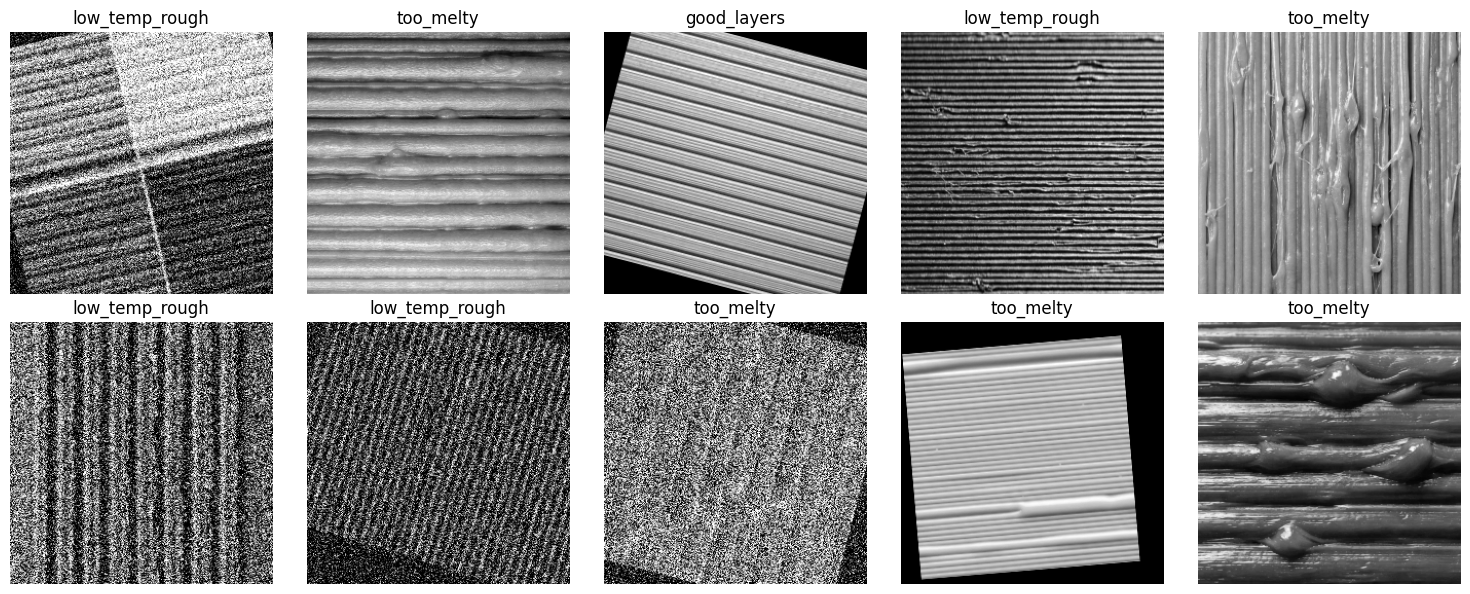

In [12]:
# Display a random sample of up to 10 images after augmentation
import random
n_show = min(10, len(X_images))
if n_show == 0:
    print('No images available to display.')
else:
    idxs = random.sample(range(len(X_images)), n_show)
    rows = 2 if n_show > 5 else 1
    cols = 5 if n_show >= 5 else n_show
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(rows, cols, i+1)
        img = X_images[idx]
        if img.ndim == 3 and img.shape[2] == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray')
        plt.axis('off')
        lbl = INV_CLASS_MAP[int(y[idx])] if y is not None else 'N/A'
        plt.title(str(lbl))
    plt.tight_layout()
    plt.show()

In [13]:
# Split indices to keep image<->feature alignment (stratified)
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
# Training / test feature arrays
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
# Scale features
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print('Feature shape:', X.shape)
print('Train/test sizes:', X_train_s.shape, X_test_s.shape)

Feature shape: (868, 8)
Train/test sizes: (694, 8) (174, 8)


In [14]:
# Prepare feature sequences for Conv1D
n_features = X_train_s.shape[1]
X_train_cnn = X_train_s.reshape(-1, n_features, 1)
X_test_cnn = X_test_s.reshape(-1, n_features, 1)
# Convert labels to categorical for Keras
num_classes = len(CLASS_MAP)
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)
print('CNN input shape (train):', X_train_cnn.shape)

CNN input shape (train): (694, 8, 1)


## Section 6 — Build The Model
We are building the CNN model that will be trained on the extracted features from the images

In [15]:
# Build a Conv1D model over the feature sequence
from tensorflow.keras import layers, models, callbacks

def make_feature_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=inp, outputs=out)
    return model

input_shape = X_train_cnn.shape[1:]  # (n_features, 1)
feature_cnn = make_feature_cnn(input_shape, num_classes)
feature_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
feature_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,235 (90.76 KB)

 Trainable params: 23,235 (90.76 KB)

 Non-trainable params: 0 (0.00 B)

## Section 7 — Early Stopping Training
We are using a regularization technique that terminates training before a model starts overfitting.

In [16]:
# Train with EarlyStopping
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
history = feature_cnn.fit(X_train_cnn, y_train_cat, validation_split=0.1, epochs=60, batch_size=32, callbacks=[es], verbose=1)
print('Training finished')

Epoch 1/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3782 - loss: 1.0974 - val_accuracy: 0.4143 - val_loss: 1.0700
Epoch 2/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4808 - loss: 1.0559 - val_accuracy: 0.6143 - val_loss: 1.0402
Epoch 3/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5641 - loss: 1.0098 - val_accuracy: 0.6000 - val_loss: 0.9854
Epoch 4/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5737 - loss: 0.9650 - val_accuracy: 0.5571 - val_loss: 0.9537
Epoch 5/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5865 - loss: 0.9311 - val_accuracy: 0.5571 - val_loss: 0.9291
Epoch 6/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5978 - loss: 0.9083 - val_accuracy: 0.6286 - val_loss: 0.8823
Epoch 7/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6250 - loss: 0.8751 - val_accuracy: 0.6000 - val_loss: 0.8637
Epoch 8/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6426 - loss: 0.8409 - val_accuracy: 0.6286 - val_loss

## Section 8 — Model Evaluation
We are evaluating the model to check how it performed and we are plotting the Confusion Matrix so we have a visual representation of the False positives/negatives and True positives/negatives

Test accuracy: 0.6667, loss: 0.7492
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Classification Report:
                precision    recall  f1-score   support

low_temp_rough       0.65      0.57      0.61        60
   good_layers       0.65      0.73      0.69        63
     too_melty       0.71      0.71      0.71        51

      accuracy                           0.67       174
     macro avg       0.67      0.67      0.67       174
  weighted avg       0.67      0.67      0.66       174



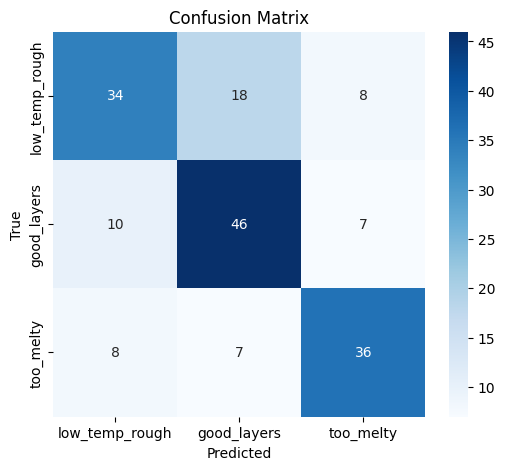

In [27]:
# Evaluate on test set
test_loss, test_acc = feature_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f'Test accuracy: {test_acc:.4f}, loss: {test_loss:.4f}')
y_prob = feature_cnn.predict(X_test_cnn)
y_pred = np.argmax(y_prob, axis=1)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=[INV_CLASS_MAP[i] for i in sorted(INV_CLASS_MAP.keys())]))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[INV_CLASS_MAP[i] for i in sorted(INV_CLASS_MAP.keys())], yticklabels=[INV_CLASS_MAP[i] for i in sorted(INV_CLASS_MAP.keys())])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Section 9 — Save Model
We are saving the model so it can be used later without the need to train it again.

In [18]:
# Save model and scaler
feature_cnn.save('feature_cnn.h5')
joblib.dump(scaler, 'scaler.joblib')
print('Saved feature_cnn.h5 and scaler.joblib')

Saved feature_cnn.h5 and scaler.joblib


## Section 10 — Plot Training and Validation loss and Accuracy
We are plotting the training and validation loss and accuracy to have a visual representation of how our model was trained.

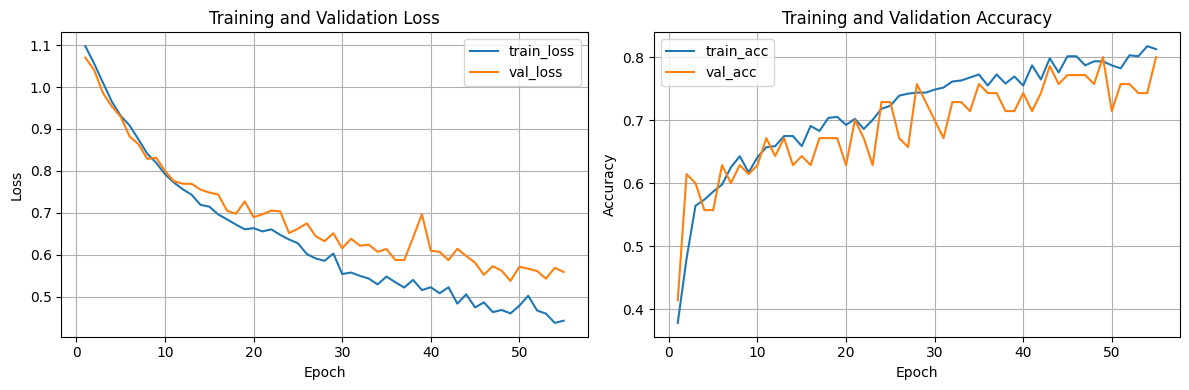

In [19]:
# Plot training / validation loss and accuracy from `history`
if 'history' in globals() and hasattr(history, 'history'):
    h = history.history
    epochs_ran = range(1, len(h.get('loss', [])) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_ran, h.get('loss', []), label='train_loss')
    if 'val_loss' in h:
        plt.plot(epochs_ran, h['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(1,2,2)
    if 'accuracy' in h or 'acc' in h:
        acc = h.get('accuracy', h.get('acc'))
        plt.plot(epochs_ran, acc, label='train_acc')
        if 'val_accuracy' in h or 'val_acc' in h:
            val_acc = h.get('val_accuracy', h.get('val_acc'))
            plt.plot(epochs_ran, val_acc, label='val_acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid(True)
    else:
        plt.text(0.5, 0.5, 'No accuracy data in history', ha='center')
    plt.tight_layout()
    plt.show()
else:
    print('No training history found. Make sure the training cell ran and `history` exists.')

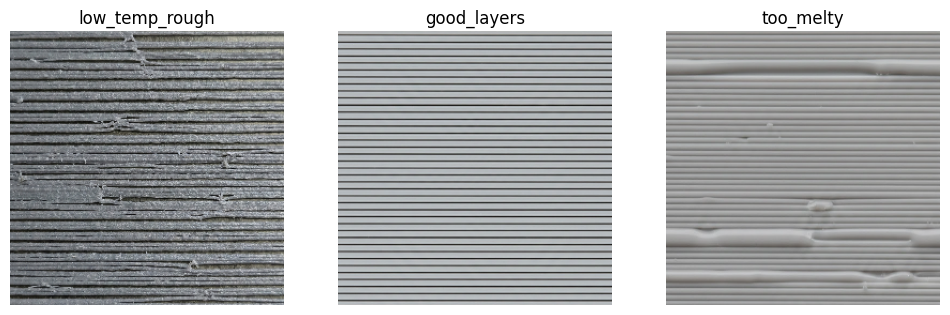

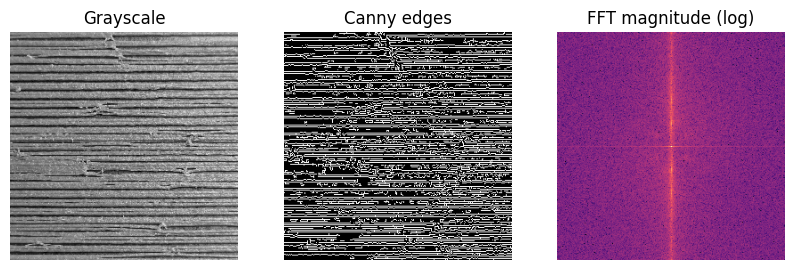

In [20]:
# Show sample image per class
plt.figure(figsize=(12,4))
for i, class_name in enumerate(CLASS_MAP.keys()):
    class_dir = os.path.join(DATASET_PATH, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))] if os.path.isdir(class_dir) else []
    if len(files) == 0:
        continue
    img = cv2.imread(os.path.join(class_dir, files[0]), cv2.IMREAD_COLOR)
    img = cv2.resize(img, (256,256))
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis('off')
plt.show()
# Edge detection visualization for a sample image
sample_class = next(iter(CLASS_MAP.keys()))
sample_files = [f for f in os.listdir(os.path.join(DATASET_PATH, sample_class)) if f.lower().endswith(('.jpg', '.png'))] if os.path.isdir(os.path.join(DATASET_PATH, sample_class)) else []
if sample_files:
    sample_path = os.path.join(DATASET_PATH, sample_class, sample_files[0])
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    edges = cv2.Canny(img, 100, 200)
    # FFT magnitude visualization
    f = np.fft.fftshift(np.fft.fft2(img))
    mag = np.log1p(np.abs(f))
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title('Grayscale')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny edges')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(mag, cmap='magma')
    plt.title('FFT magnitude (log)')
    plt.axis('off')
    plt.show()

## Section 11 — Single Image Prediction Function
This helper loads an image, extracts features, scales them, predicts with the trained model, prints the predicted label, and displays the image.

In [21]:
def predict_single_image(image_path, show=True):
    # Predict using feature-based Conv1D model
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        print('Unable to read image:', image_path)
        return None
    img_resized = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    # extract features, scale, reshape for Conv1D
    feats = extract_features(gray).reshape(1, -1)
    try:
        feats_s = scaler.transform(feats)
    except Exception as e:
        print('Scaler not found or error scaling features:', e)
        return None
    feats_cnn = feats_s.reshape(1, n_features, 1)
    prob = feature_cnn.predict(feats_cnn)
    pred = int(np.argmax(prob, axis=1)[0])
    pred_name = INV_CLASS_MAP.get(pred, str(pred))
    print(f'Predicted label: {pred} ({pred_name})')
    if show:
        plt.figure(figsize=(4,4))
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Predicted: {pred_name}')
        plt.show()
    return pred, pred_name

Found 30 image(s) in dataset\TEST
---
Testing image: dataset\TEST\8 (3).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted label: 0 (low_temp_rough)


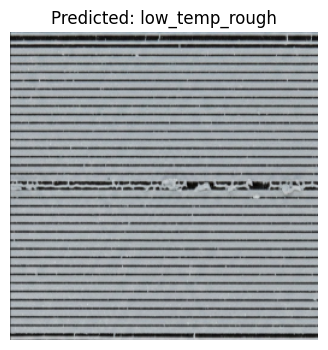

Prediction: (0, 'low_temp_rough')
---
Testing image: dataset\TEST\8.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted label: 2 (too_melty)


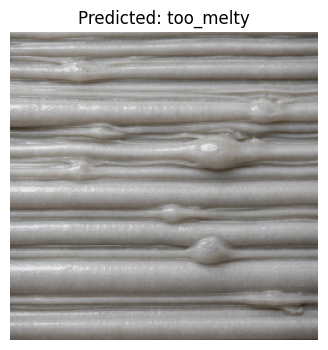

Prediction: (2, 'too_melty')
---
Testing image: dataset\TEST\9 (2).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted label: 1 (good_layers)


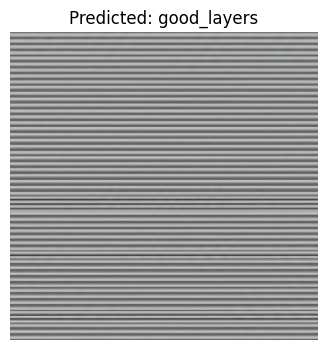

Prediction: (1, 'good_layers')
---
Testing image: dataset\TEST\9 (3).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted label: 0 (low_temp_rough)


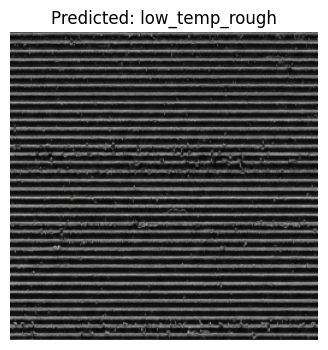

Prediction: (0, 'low_temp_rough')
---
Testing image: dataset\TEST\9.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted label: 2 (too_melty)


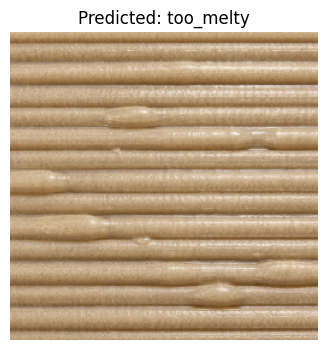

Prediction: (2, 'too_melty')


In [22]:
# Run prediction for every image in DATASET_PATH/TEST and show results
import os
class_dir = os.path.join(DATASET_PATH, 'TEST')
if os.path.isdir(class_dir):
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        print(f'Found {len(files)} image(s) in', class_dir)
        for fname in files[-5:]:
            img_path = os.path.join(class_dir, fname)
            print('---')
            print('Testing image:', img_path)
            try:
                res = predict_single_image(img_path, show=True)
                print('Prediction:', res)
            except Exception as e:
                print('Error predicting', img_path, ':', e)
    else:
        print('No images found in', class_dir)
else:
    print('Class folder not found:', class_dir)

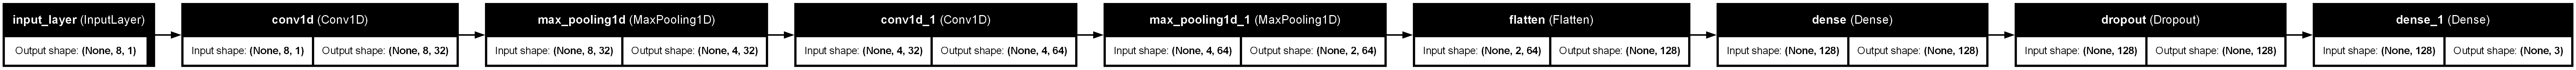

In [26]:
from tensorflow.keras.utils import plot_model

plot_model(
    feature_cnn,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # Left → Right
)